# TASK 1

### PART A

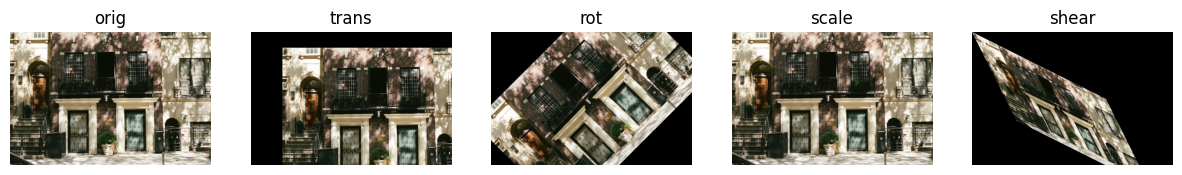

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/i1.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
r,c=img.shape[:2]

M_t=np.float32([[1,0,100],[0,1,50]])
t=cv2.warpAffine(img,M_t,(c,r))

M_r=cv2.getRotationMatrix2D((c/2,r/2),45,1)
rot=cv2.warpAffine(img,M_r,(c,r))

M_s=np.float32([[1.5,0,0],[0,1.5,0]])
scl=cv2.warpAffine(img,M_s,(int(c*1.5),int(r*1.5)))

M_sh=np.float32([[1,0.5,0],[0.5,1,0]])
shr=cv2.warpAffine(img,M_sh,(int(c*1.5),int(r*1.5)))

fig,ax=plt.subplots(1,5,figsize=(15,4))
for a,i,t in zip(ax,[img,t,rot,scl,shr],['orig','trans','rot','scale','shear']):
  a.imshow(i);a.set_title(t);a.axis('off')
plt.show()

### PART B

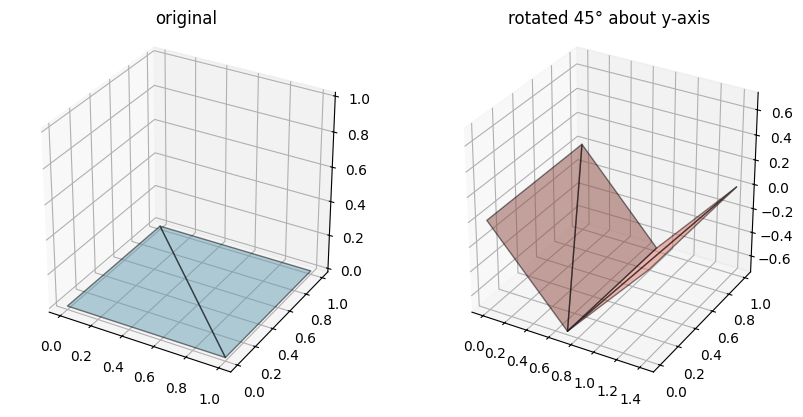

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,5))
x=np.array([0,1,1,0,0,1,1,0])
y=np.array([0,0,1,1,0,0,1,1])
z=np.array([0,0,0,0,1,1,1,1])

ax1=fig.add_subplot(121,projection='3d')
ax1.plot_trisurf(x,y,z,alpha=0.5,color='skyblue',edgecolor='k')
ax1.set_title('original')
ax1.set_box_aspect([1,1,1])

theta=np.radians(45)
R=np.array([[np.cos(theta),0,np.sin(theta)],[0,1,0],[-np.sin(theta),0,np.cos(theta)]])
pts=np.vstack((x,y,z))
rpts=R@pts

ax2=fig.add_subplot(122,projection='3d')
ax2.plot_trisurf(rpts[0],rpts[1],rpts[2],alpha=0.5,color='salmon',edgecolor='k')
ax2.set_title('rotated 45° about y-axis')
ax2.set_box_aspect([1,1,1])

plt.show()


### PART C

In [ ]:
d=np.array([3,4])
p=np.array([3,4,1])
M=np.array([[1,0,2],[0,1,1],[0,0,1]])
new=M@p
print("Point in 2D:",d)
print('Homodenous Cordinates:',p)
print('Transformed:',new)

Point in 2D: [3 4]
Homodenous Cordinates: [3 4 1]
Transformed: [5 5 1]


2D Point: (x,y)

Homogeneous Coordinates: (x,y,1)

General Homogeneous Coordinates: (x,y,w) , w != 0

The role of the extra coordinate is that it lets us represent translation using matrix multiplication, and thus enables consistent linear operations for all transformations.

### PART D

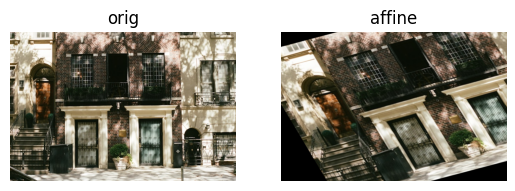

In [ ]:
pts1=np.float32([[50,50],[200,50],[50,200]])
pts2=np.float32([[10,100],[200,50],[100,250]])
M=cv2.getAffineTransform(pts1,pts2)
out=cv2.warpAffine(img,M,(c,r))

plt.subplot(1,2,1);plt.imshow(img);plt.axis('off');plt.title('orig')
plt.subplot(1,2,2);plt.imshow(out);plt.axis('off');plt.title('affine')
plt.show()

After affine transform, straight lines remain straight, only the geometry (scale, rotation, shear, translate) changes.

### PART E

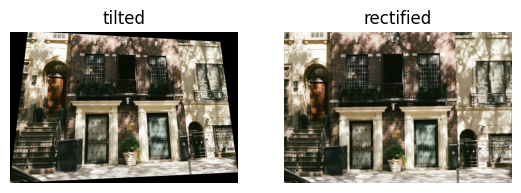

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

img=cv2.imread('/content/i1.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
r,c=img.shape[:2]

pts1=np.float32([[0,0],[c,0],[0,r],[c,r]])
pts2=np.float32([[50,0],[c-50,30],[0,r],[c,r-30]])
H1=cv2.getPerspectiveTransform(pts1,pts2)
tilt=cv2.warpPerspective(img,H1,(c,r))

H2=cv2.getPerspectiveTransform(pts2,pts1)
rect=cv2.warpPerspective(tilt,H2,(c,r))

plt.figure(figsize=(10,4))
plt.subplot(1,3,2);plt.imshow(tilt);plt.title('tilted');plt.axis('off')
plt.subplot(1,3,3);plt.imshow(rect);plt.title('rectified');plt.axis('off')
plt.show()


# TASK 2

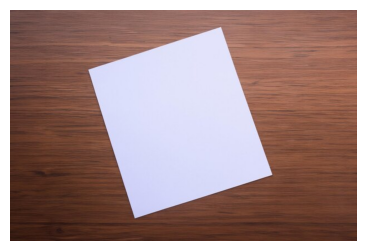

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/doc3.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 3))
plt.imshow(img)
plt.axis('off')
plt.show()

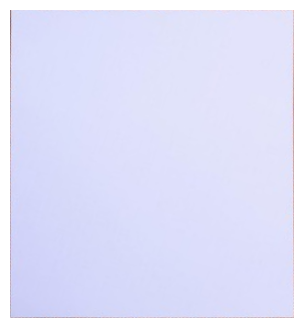

In [ ]:
img = cv2.imread('/content/doc3.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        doc_cnt = approx
        break

pts = doc_cnt.reshape(4, 2)
rect = np.zeros((4, 2), dtype="float32")

s = pts.sum(axis=1)
rect[0] = pts[np.argmin(s)]
rect[2] = pts[np.argmax(s)]

diff = np.diff(pts, axis=1)
rect[1] = pts[np.argmin(diff)]
rect[3] = pts[np.argmax(diff)]

(widthA, widthB) = np.linalg.norm(rect[2]-rect[3]), np.linalg.norm(rect[1]-rect[0])
(heightA, heightB) = np.linalg.norm(rect[1]-rect[2]), np.linalg.norm(rect[0]-rect[3])
maxWidth, maxHeight = int(max(widthA, widthB)), int(max(heightA, heightB))

dst = np.array([[0,0],[maxWidth-1,0],[maxWidth-1,maxHeight-1],[0,maxHeight-1]], dtype="float32")
M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(img_rgb, M, (maxWidth, maxHeight))

plt.figure(figsize=(6,4))
plt.imshow(warped)
plt.axis('off')
plt.show()

# TASK 3

In [ ]:
import cv2
import numpy as np

video_path = '/content/cvid2.mp4'

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

fx = fy = width * 0.87
cx = width / 2.0
cy = height / 2.0

camera_matrix = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.array([-0.27, 0.11, 0.0, 0.0, -0.02], dtype=np.float32)

print(f"Video Resolution: {width}x{height}")
print(f"\nCamera Matrix (Hero 12/13 Wide FOV):")
print(camera_matrix)
print(f"\nDistortion Coefficients:")
print(dist_coeffs)

Video Resolution: 854x480

Camera Matrix (Hero 12/13 Wide FOV):
[[742.98   0.   427.  ]
 [  0.   742.98 240.  ]
 [  0.     0.     1.  ]]

Distortion Coefficients:
[-0.27  0.11  0.    0.   -0.02]


In [ ]:
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (width, height), 0.9, (width, height)
)

map1, map2 = cv2.initUndistortRectifyMap(
    camera_matrix, dist_coeffs, None, new_camera_matrix,
    (width, height), cv2.CV_32FC1
)

out = cv2.VideoWriter('undistorted_gopro.mp4', fourcc, fps, (width, height))

print(f"Total Frames: {total_frames}")
print(f"FPS: {fps}")
print(f"ROI: {roi}")

Total Frames: 3703
FPS: 29
ROI: (12, 20, 829, 438)


In [ ]:
frame_count = 0
print_interval = 50

while True:
    ret, frame = cap.read()
    if not ret:
        break

    undistorted = cv2.remap(frame, map1, map2, cv2.INTER_LINEAR)

    x, y, w, h = roi
    if w > 0 and h > 0:
        undistorted = undistorted[y:y+h, x:x+w]
        undistorted = cv2.resize(undistorted, (width, height))

    out.write(undistorted)

    frame_count += 1
    if frame_count % print_interval == 0:
        progress = (frame_count / total_frames) * 100
        print(f"[{frame_count}/{total_frames}] {progress:.1f}% complete")

cap.release()
out.release()

print(f"\n✓ Processing Complete!")
print(f"Total Frames Processed: {frame_count}")
print(f"Output: undistorted_gopro.mp4")

[50/3703] 1.4% complete
[100/3703] 2.7% complete
[150/3703] 4.1% complete
[200/3703] 5.4% complete
[250/3703] 6.8% complete
[300/3703] 8.1% complete
[350/3703] 9.5% complete
[400/3703] 10.8% complete
[450/3703] 12.2% complete
[500/3703] 13.5% complete
[550/3703] 14.9% complete
[600/3703] 16.2% complete
[650/3703] 17.6% complete
[700/3703] 18.9% complete
[750/3703] 20.3% complete
[800/3703] 21.6% complete
[850/3703] 23.0% complete
[900/3703] 24.3% complete
[950/3703] 25.7% complete
[1000/3703] 27.0% complete
[1050/3703] 28.4% complete
[1100/3703] 29.7% complete
[1150/3703] 31.1% complete
[1200/3703] 32.4% complete
[1250/3703] 33.8% complete
[1300/3703] 35.1% complete
[1350/3703] 36.5% complete
[1400/3703] 37.8% complete
[1450/3703] 39.2% complete
[1500/3703] 40.5% complete
[1550/3703] 41.9% complete
[1600/3703] 43.2% complete
[1650/3703] 44.6% complete
[1700/3703] 45.9% complete
[1750/3703] 47.3% complete
[1800/3703] 48.6% complete
[1850/3703] 50.0% complete
[1900/3703] 51.3% complete
[

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_path = 'undistorted_gopro.mp4'

mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=800 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

# TASK 4

In [ ]:
!sudo apt update
!sudo apt install -y colmap

In [ ]:
!colmap -h

In [ ]:
import zipfile
with zipfile.ZipFile('/content/south-building.zip', 'r') as z:
    z.extractall('/content/')

In [ ]:
IMAGE_DIR = "/content/south-building/images"
PROJECT_DIR = "/content/colmap_output"

!mkdir -p $PROJECT_DIR

In [ ]:
DB_PATH     = "/content/south-building/database.db"
SPARSE_DIR  = "/content/south-building/sparse"

In [ ]:
!mkdir -p /content/colmap_output/dense

In [ ]:
!colmap model_converter \
    --input_path /content/south-building/sparse/ \
    --output_path /content/sparse_model.ply \
    --output_type PLY

In [ ]:
!mkdir -p /content/sparse_model

!colmap model_converter \
    --input_path /content/south-building/sparse/ \
    --output_path /content/sparse_model \
    --output_type TXT


In [ ]:
import numpy as np
import plotly.graph_objects as go

# Load sparse points from TXT
points = []
with open("/content/sparse_model/points3D.txt") as f:
    lines = f.readlines()[3:]  # skip header
    for line in lines:
        pts = line.strip().split()
        x, y, z = float(pts[1]), float(pts[2]), float(pts[3])
        points.append([x, y, z])
points = np.array(points)

# Plot inline
fig = go.Figure(data=[go.Scatter3d(
    x=points[:,0], y=points[:,1], z=points[:,2],
    mode='markers',
    marker=dict(size=2, color=points[:,2], colorscale='Viridis')
)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()